In [1]:
import os
# MUST be set BEFORE torch (or fastai) is ever imported.
# Without this, any MPS-unsupported op (e.g. adaptive_avg_pool2d, certain loss ops)
# raises RuntimeError instead of silently falling back to CPU.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

!pip install -Uqq fastbook


In [2]:
#hide
from fastbook import *

##  Deep-learning
It is a subset of machine learning that uses neural networks with three or more layers,  to learn directly from data, instead of being explicitly told what to look for, these networks automatically  discover patterns and features in large datasets, making them particularly effective for tasks like image recognition, natural language processing,r
speech recognition.

# Model Training, Validation & Deployment Pipeline

---

## Phase 1 — Data Preparation

| Step | Action |
|------|--------|
| i | **Acquire the Dataset** — Source raw data relevant to the problem. |
| ii | **Label the Data** — Assign ground-truth labels to each sample. |
| iii | **Categorize the Data** — Organize data into meaningful classes or groups. |
| iv | **Split the Data** — Partition into a **Training Set** and a held-out **Validation Set**. |
| v | **Train** — Fit the model on the training data and evaluate training-time performance. |
| vi | **Validate** — Assess generalization by evaluating on the unseen validation set. |

---

## Phase 2 — Training Loop

### 1. Initialize Model Parameters
Set all weights and biases to their starting values (e.g., random initialization or a pretrained checkpoint).

---

### 2. Define the Loss Function
The loss function quantifies *how wrong* the model's predictions are relative to the ground truth.

| Problem Type | Common Loss Function |
|---|---|
| Classification | Cross-Entropy Loss |
| Regression | Mean Squared Error (MSE) |

---

### 3. Choose an Optimizer
The optimizer adjusts model parameters to *minimize* the loss.

| Optimizer | Characteristic |
|---|---|
| **SGD** | Simple, reliable, requires careful LR tuning |
| **Adam** | Adaptive learning rates, robust default choice |

---

### 4. Set the Learning Rate
The learning rate controls the **step size** taken at each update iteration toward the loss minimum.

> A rate too high → overshooting; too low → painfully slow convergence.

---

### 5. Iterate Over Epochs
One **epoch** = one complete pass through the entire training dataset.  
Training runs for multiple epochs until the model converges.

---

### 6. Mini-Batch Processing
Rather than processing all data at once, the dataset is divided into **mini-batches** — small subsets processed sequentially per epoch. This balances computational efficiency with stable gradient estimates.

---

### 7. Forward Pass
For each mini-batch, the model computes predictions using its **current parameters**.

```
Input → Model → Predictions (ŷ)
```

---

### 8. Compute Loss
The loss function measures the **discrepancy** between predictions `ŷ` and actual labels `y`.

```
Loss = L(ŷ, y)
```

---

### 9. Backward Pass (Backpropagation)
The computed loss is propagated **backward** through the network.  
Gradients are calculated — quantifying *how much each weight contributed to the error*.

```
∂Loss/∂w  →  for every weight w in the network
```

---

### 10. Update Weights
The optimizer applies the gradients to update all model parameters, moving them in the direction that **reduces the loss**.

```
w  ←  w − η · ∂Loss/∂w
```
where `η` is the learning rate.

---

### 11. Periodic Validation
After each epoch (or a fixed number of iterations), evaluate on the **validation set** to:

- Monitor generalization to unseen data
- Detect **overfitting** — when training loss falls but validation loss rises

> **Overfitting signal:** High training accuracy + Low validation accuracy = the model has memorized, not learned.

---

## Training Loop — Summary Flow

```
Initialize Parameters
        │
        ▼
┌─── For each Epoch ───────────────────────────────────┐
│                                                       │
│   For each Mini-Batch:                                │
│       1. Forward Pass  →  Generate Predictions        │
│       2. Compute Loss  →  Measure Error               │
│       3. Backward Pass →  Calculate Gradients         │
│       4. Update Weights → Minimize Loss               │
│                                                       │
│   End of Epoch → Evaluate on Validation Set           │
└───────────────────────────────────────────────────────┘
        │
        ▼
  Converged? → Proceed to Deployment
```

Topics to cover in the next section:
Deep Dive into Deep Learning
Architecture of the computer vision model
NLP Model
a tabular Model
How to Create a architecture that matches the needs of your particular domain.
How to get the best possible results from the training process.
How do you make things faster?
How to  you have to change as your database changes?


### Need to learn
1. Different types of the layers.
2. Regularization techniques.
3. Optimization techniques/ Optimizers
4. How to put layers into a model architecture.
5. Labelling techniques

In [3]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)


Need to extract the breed of each pet 
in this case need to understand how  the data is laid out.
Such details of data layout are a vital piece of the deep learning puzzle. Data is usually provided in one of these two ways
Individual files representing items of data, such as text documents or images, possibly organized into folders or with filenames representing information about those items
A table of data, such as in CSV format, where each row is an item which may include filenames providing a connection between the data in the table and data in other formats, such as text documents and images

In [4]:
# Lets see what is in   dataset
Path.BASE_PATH=path

In [5]:
path.ls()

[Path('images'), Path('annotations')]

https://www.google.com/url?q=https%3A%2F%2Fwww.robots.ox.ac.uk%2F%7Evgg%2Fdata%2Fpets%2Fhttps://www.google.com/url?q=https%3A%2F%2Fwww.robots.ox.ac.uk%2F%7Evgg%2Fdata%2Fpets%2F

annotation directory tells us it  contains   the information about where the pets are   rather than what they   are 

As we are doing classification  we are care about the what the pets are instead of where they are.
so ignore  the annotation directory and focus on the images directory which contains the images of the pets and the labels are in the file name itself.

In [6]:
(path/"images").ls()
print(path)

/Users/manojkumar/.fastai/data/oxford-iiit-pet


Obeservation 
7393--> number of files in the images directory
pug_52.jpg
asset_hound_112.jpg
somename_number.extension 
somename_otherName_number.extension 


In [7]:
#Lets Check Further 
fname = (path/"images").ls()[0]
fname,

(Path('images/Egyptian_Mau_167.jpg'),)

In [8]:
#use the regex against the fname
re.findall(r'^(.*)_\d+.jpg$', fname.name)

['Egyptian_Mau']

In [9]:
#re works for one example now lets use it for all  data set
pets=DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=using_attr(RegexLabeller(r'^(.*)_\d+.jpg$'), 'name'),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)
dls=pets.dataloaders(path/"images")


item_tfms=Resize(460),
batch_tfms=aug_transforms(size=224, min_scale=0.75),
here lines implement a fastai data augmentation strategy which we call presizing. Presizing is a particular way to do image augmentation that is designed to minimize data destruction while maintaining good performance. The idea is to first resize the image to a larger size (in this case, 460 pixels) and then apply random augmentations that may include cropping, flipping, rotating, etc., while ensuring that the final output size is 224 pixels. This approach allows the model to learn from a variety of augmented images while preserving important features and details in the original image.

Copied 'Egyptian_Mau_167.jpg' to '/Users/manojkumar/workspace/project26/notebooks/images/Egyptian_Mau_167.jpg'
You can now find the image in: /Users/manojkumar/workspace/project26/notebooks/images


[Path('/Users/manojkumar/workspace/project26/notebooks/images/Egyptian_Mau_167.jpg')]

Displaying the copied image:


<Axes: >

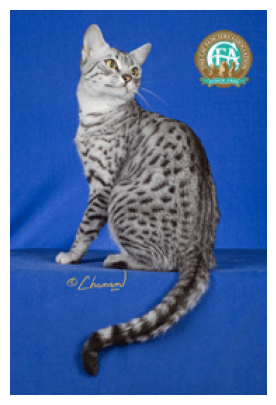

In [10]:
#helper function to copy  the image 
import shutil
from pathlib import Path

# Get the path to the first image in the fastai pets dataset
source_image_path = (path/"images").ls()[0]

# Define the target directory in the CWD
target_dir = Path.cwd() / 'images'

# Create the target directory if it doesn't exist
target_dir.mkdir(exist_ok=True)

# Define the destination path for the copied image
destination_image_path = target_dir / source_image_path.name

# Copy the image
shutil.copy(source_image_path, destination_image_path)

print(f"Copied '{source_image_path.name}' to '{destination_image_path}'")
print(f"You can now find the image in: {target_dir}")

# Verify the image is in the CWD's 'images' folder
display(target_dir.ls())
#load and display the Image
print("Displaying the copied image:")
img=PILImage.create(destination_image_path)
img.show()

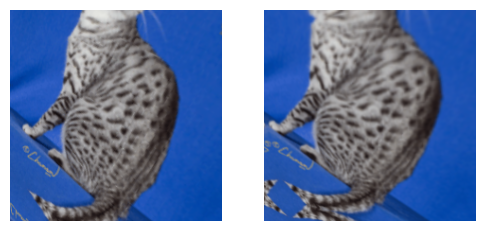

In [11]:
#hide_input
#id interpolations
#caption A comparison of fastai's data augmentation strategy (left) and the traditional approach (right).

# DataBlock defines the blueprInt of the dataset pipeline:
#   ImageBlock()    → each input item is an image
#   CategoryBlock() → each label is a category (class name)
#   get_y=parent_label → label is derived from the parent folder name
#   item_tfms=Resize(224) → resize every image to 224x224 BEFORE batching
#                           (using 224 here avoids the >2x downscale that breaks affine_coord)
dblock1 = DataBlock(blocks=(ImageBlock(), CategoryBlock()),
                   get_y=parent_label,
                   item_tfms=Resize(224))

# Uses the image copied in the previous cell from the pets dataset images/ folder
img_path = (Path.cwd()/'images').ls()[0]      # pick the first image from local images/ folder

# dataloaders() creates train/valid DataLoaders from the list of 100 copies of the same image
# bs=8 → process 8 images per batch
dls1 = dblock1.dataloaders([img_path]*100, bs=8)

# Override the training index generator so the SAME image is always returned
# Inf.ones → an infinite iterator of 1s, so index 1 (same image) is always picked
dls1.train.get_idxs = lambda: Inf.ones

# one_batch() returns one mini-batch: x=images tensor (B,C,H,W), y=labels tensor
x, y = dls1.valid.one_batch()

# Create a 1-row, 2-column subplot to show both images side-by-side
_,axs = subplots(1, 2)

# ── TRADITIONAL APPROACH (right subplot) ─────────────────────────────────────
# Clone x so we don't modify the original batch
x1 = TensorImage(x.clone())

# affine_coord(sz=224): applies an affine grid transformation and resizes to 224x224.
# With input already at 224, this is effectively a no-op resize (identity transform),
# but it initialises the coordinate grid needed by downstream transforms.
x1 = x1.affine_coord(sz=224)

# rotate: randomly rotates the image up to 30 degrees. p=1. means always apply.
x1 = x1.rotate(draw=30, p=1.)

# zoom: randomly zooms in by factor 1.2 (i.e. 20% zoom). p=1. means always apply.
x1 = x1.zoom(draw=1.2, p=1.)

# warp: applies a perspective warp — shifts the grid in x and y direction.
# draw_x=-0.2, draw_y=0.2 controls the distortion amount. p=1. always applies.
# PROBLEM: each transform above applies a SEPARATE grid_sample() call,
# meaning the image is interpolated 4 times → quality degrades each time.
x1 = x1.warp(draw_x=-0.2, draw_y=0.2, p=1.)

# ── FASTAI PRESIZING PIPELINE (left subplot) ──────────────────────────────────
# setup_aug_tfms() creates a list of GPU-optimised augmentation transforms.
# Each transform here accepts a size= argument so they know the OUTPUT size upfront.
tfms = setup_aug_tfms([
    Rotate(draw=30, p=1, size=224),               # rotate up to 30 degrees, output 224x224
    Zoom(draw=1.2, p=1., size=224),               # zoom by 1.2x, output 224x224
    Warp(draw_x=-0.2, draw_y=0.2, p=1., size=224) # perspective warp, output 224x224
])

# Pipeline(tfms) chains all transforms together.
# KEY ADVANTAGE: fastai FUSES all affine transforms into a SINGLE grid_sample() call
# → the image is only interpolated ONCE, preserving more quality than the traditional way.
x = Pipeline(tfms)(x)

# Show fastai pipeline result on the LEFT (x[0] = first image in the batch)
TensorImage(x[0]).show(ctx=axs[0])

# Show traditional sequential result on the RIGHT (x1[0] = first image in the batch)
TensorImage(x1[0]).show(ctx=axs[1]);

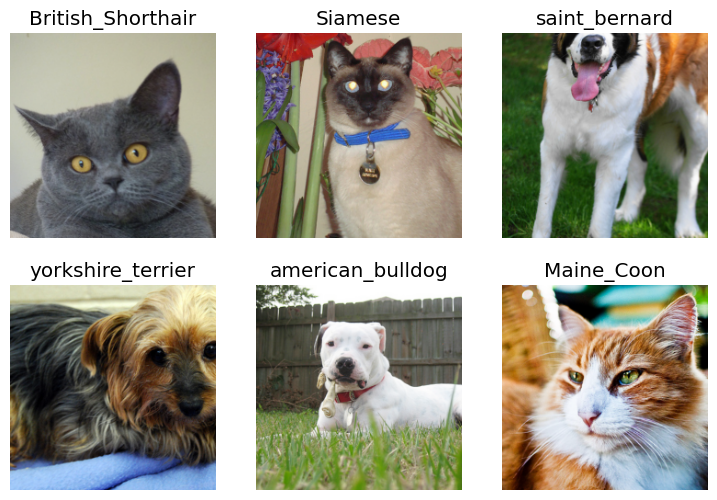

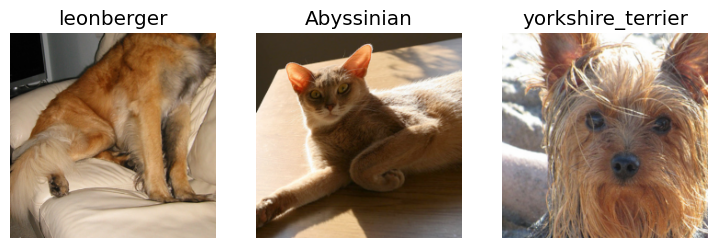

In [12]:
#before training always check the data
dls.show_batch(max_n=6)
dls.show_batch(nrows=1, ncols=3)


In [13]:
# Before proceding further  use the summary method to make sure everything is in place
#hide_output
pets1 = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                 item_tfms=Resize(224))  # Required: all images must be same size before batching
pets1.summary(path/"images")

Setting-up type transforms pipelines
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      /Users/manojkumar/.fastai/data/oxford-iiit-pet/images/saint_bernard_60.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=375x500
  Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      /Users/manojkumar/.fastai/data/oxford-iiit-pet/images/saint_bernard_60.jpg
    applying partial gives
      saint_bernard
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(30)

Final sample: (PILImage mode=RGB size=375x500, TensorCategory(30))


Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'a

Here Notice one thing How we went from a file name to sample(the tuple(image, category)), this is the power of the data block API, it allows us to easily define how to get the labels from the file names using the `get_y` parameter and the `RegexLabeller` function. This way we can easily extract the breed of each pet from the file name and use it as the label for our classification task.
If we found data looks to be write then plan to train  a  simple model
For the reason we will use the sample model to  test 
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

In [14]:
import torch
import torch.nn.functional as F

# ── MPS SETUP ────────────────────────────────────────────────────────────────
# Apple Silicon MPS supports most ops but has a known bug in adaptive_avg_pool2d:
# input sizes must be divisible by output sizes, otherwise it raises RuntimeError.
# PYTORCH_ENABLE_MPS_FALLBACK only covers ops that are UNIMPLEMENTED on MPS;
# it does NOT cover ops that are implemented but buggy (like this pool case).
# Fix: monkey-patch F.adaptive_avg_pool2d to silently fall back to CPU for that
# specific op while keeping everything else on MPS.

_orig_pool = F.adaptive_avg_pool2d

def _mps_safe_pool(input, output_size):
    try:
        return _orig_pool(input, output_size)
    except RuntimeError:
        # Non-divisible sizes: run on CPU, return result on original device
        return _orig_pool(input.cpu(), output_size).to(input.device)

F.adaptive_avg_pool2d = _mps_safe_pool
torch.nn.functional.adaptive_avg_pool2d = _mps_safe_pool   # alias used by some versions

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Build dataloaders with device= directly (NOT via defaults.device beforehand,
# which would push DataBlock validation ops onto MPS and crash).
dls = pets.dataloaders(path/"images", device=device)

# Safe to set global default now — model + optimizer will also land on MPS
defaults.device = device

# vision_learner: binds data + ResNet34 pretrained backbone + loss + optimizer
learn = vision_learner(dls, resnet34, metrics=error_rate)

# fine_tune(2): 2-stage transfer learning
# Stage 1 — freeze backbone, train only the new classification head for 1 epoch
# Stage 2 — unfreeze all layers, train with discriminative LRs for 2 epochs
learn.fine_tune(2)


Using device: mps


epoch,train_loss,valid_loss,error_rate,time
0,1.507401,0.338733,0.111637,01:22


epoch,train_loss,valid_loss,error_rate,time
0,0.515408,0.262224,0.088633,01:47
1,0.311138,0.219988,0.075101,01:47


In [ ]:
import time

def time_training(device_str, epochs=1):
    """Train for 1 freeze epoch on the given device and return elapsed seconds."""
    dev = torch.device(device_str)

    # Override global defaults so vision_learner places the model on dev
    prev_device = defaults.device
    defaults.device = dev

    try:
        _dls = pets.dataloaders(path/"images", device=dev)
        _learn = vision_learner(_dls, resnet34, metrics=error_rate)
        # Explicit guarantee: move model + optimizer state to dev regardless
        # of any global state left over from previous training runs.
        _learn.model = _learn.model.to(dev)
        _learn.dls.device = dev

        _learn.freeze()
        t0 = time.perf_counter()
        _learn.fit(epochs, lr=1e-3)
        elapsed = time.perf_counter() - t0
    finally:
        defaults.device = prev_device   # always restore to MPS

    return elapsed

print("Timing 1 epoch on CPU ...")
cpu_secs = time_training("cpu")
print(f"  CPU  : {cpu_secs:.1f}s")

if torch.backends.mps.is_available():
    print("Timing 1 epoch on MPS ...")
    mps_secs = time_training("mps")
    print(f"  MPS  : {mps_secs:.1f}s")
    print(f"  Speedup: {cpu_secs/mps_secs:.1f}× faster on MPS")
else:
    print("MPS not available on this machine.")


Timing 1 epoch on CPU ...


epoch,train_loss,valid_loss,error_rate,time


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!